In [ ]:
# Install required packages
!pip install -q plotnine geopandas scipy geodatasets

In [1]:
#| label: setup

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from plotnine import *
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Load data ─────────────────────────────────────────────────────────────

base_url = 'https://raw.githubusercontent.com/kandhurikiran/unicef-report/main/'

ind1 = pd.read_csv(base_url + 'unicef_indicator_1.csv')
ind2 = pd.read_csv(base_url + 'unicef_indicator_2.csv')
meta = pd.read_csv(base_url + 'unicef_metadata.csv')


# ── HIV: latest value per country (Total sex only) ────────────────────────
hiv_latest = (
    ind1[ind1['sex'] == 'Total']
    .sort_values('time_period')
    .groupby(['country', 'alpha_3_code'], as_index=False)
    .last()[['country', 'alpha_3_code', 'time_period', 'obs_value']]
    .rename(columns={'obs_value': 'hiv_rate', 'time_period': 'hiv_year'})
)

# ── HIV: global average + std range by year ───────────────────────────────
hiv_trend = (
    ind1[ind1['sex'] == 'Total']
    .groupby('time_period')['obs_value']
    .agg(['mean', 'min', 'max', 'std'])
    .reset_index()
    .rename(columns={'time_period': 'year', 'mean': 'avg_hiv'})
)
hiv_trend['ymin'] = hiv_trend['avg_hiv'] - hiv_trend['std']
hiv_trend['ymax'] = hiv_trend['avg_hiv'] + hiv_trend['std']

# ── Metadata: latest GDP + life expectancy per country ────────────────────
meta_latest = (
    meta.sort_values('year')
    .groupby('alpha_3_code', as_index=False)
    .last()[['alpha_3_code',
             'GDP per capita (constant 2015 US$)',
             'Life expectancy at birth, total (years)',
             'Population, total']]
    .rename(columns={
        'GDP per capita (constant 2015 US$)': 'gdp',
        'Life expectancy at birth, total (years)': 'life_exp',
        'Population, total': 'population'
    })
)

# ── Scatter dataset ───────────────────────────────────────────────────────
scatter_df = (
    hiv_latest
    .merge(meta_latest, on='alpha_3_code', how='inner')
    .dropna(subset=['gdp', 'life_exp'])
)
scatter_df['gdp_log'] = np.log10(scatter_df['gdp'])
scatter_df['income_group'] = pd.cut(
    scatter_df['gdp'],
    bins=[0, 1000, 5000, 15000, 1e9],
    labels=['Low (<$1k)', 'Lower-Middle ($1k-$5k)',
            'Upper-Middle ($5k-$15k)', 'High (>$15k)']
)

# ── Bar chart: top 20 countries ───────────────────────────────────────────
bar_df = hiv_latest.nlargest(20, 'hiv_rate').sort_values('hiv_rate', ascending=True)
bar_df['country'] = pd.Categorical(
    bar_df['country'], categories=bar_df['country'].tolist(), ordered=True
)

# ── Regression stats ──────────────────────────────────────────────────────
slope, intercept, r_val, p_val, se = stats.linregress(
    scatter_df['gdp_log'], scatter_df['hiv_rate']
)

# ── Reduction stat ────────────────────────────────────────────────────────
start_val = hiv_trend.iloc[0]['avg_hiv']
end_val   = hiv_trend.iloc[-1]['avg_hiv']
reduction = ((start_val - end_val) / start_val) * 100

print('Setup complete')
print(f'  HIV countries : {len(hiv_latest)}')
print(f'  Scatter points: {len(scatter_df)}')
print(f'  R value       : {r_val:.3f}')
print(f'  Reduction     : {reduction:.1f}%')

Setup complete
  HIV countries : 82
  Scatter points: 81
  R value       : -0.338
  Reduction     : 38.9%


## The Silent Emergency Facing the World's Children

Every year, hundreds of thousands of children are born with **HIV** - not because of any choice
of their own, but because the systems meant to protect them have failed. At the same time,
millions of girls in the world's poorest nations become mothers before they are ready, before
their bodies are ready, and long before they have the power to choose otherwise.

These two crises - **mother-to-child HIV transmission** and **adolescent birth rates** - are not
separate problems. They share the same roots: **poverty**, the absence of healthcare, and the
systematic exclusion of girls and women from education and opportunity.

This report uses UNICEF data to illuminate three uncomfortable truths:

1. **Geography is destiny.** Where a child is born remains the single strongest predictor of
   whether they will be exposed to HIV at birth.
2. **Wealth protects.** Countries with higher GDP per capita have dramatically lower HIV
   transmission rates - not because of biology, but because of access to antiretroviral treatment.
3. **Progress is real - but fragile.** Global HIV transmission rates have fallen significantly
   since 2010, but the gains are concentrated in countries that were already better resourced.

---

## Chart 1 - Where the Crisis Is: A Global Map of HIV Transmission

The map below shows the **mother-to-child HIV transmission rate** for each country.
*Darker colours represent higher transmission rates. Grey = no data.*

Total countries: 258
Countries with HIV data: 82


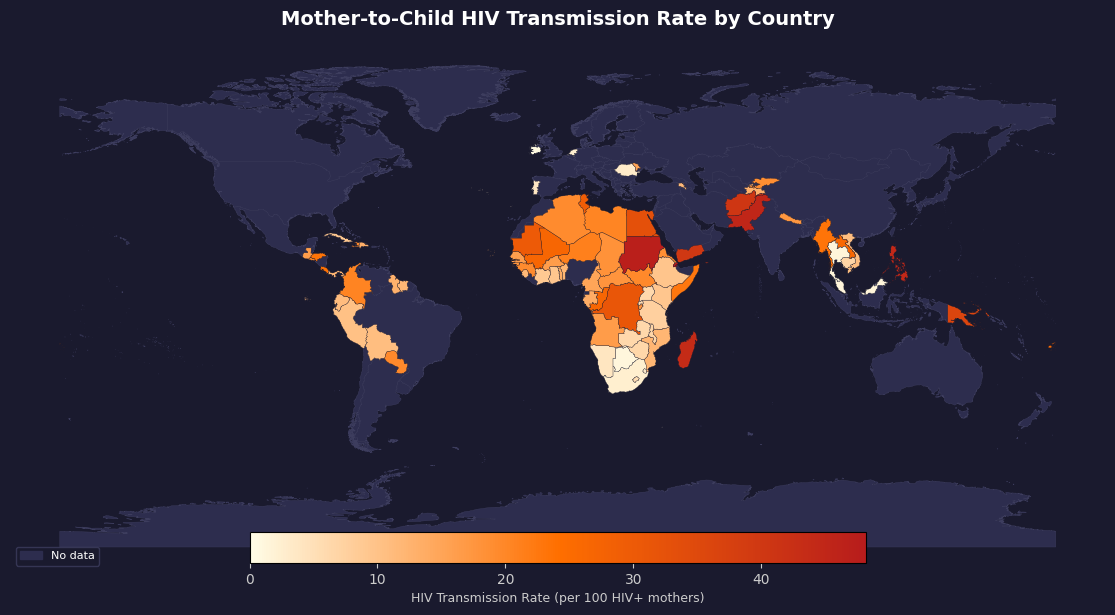

Map rendered successfully


In [ ]:
#| label: world-map

import requests
import geopandas as gpd

url = 'https://raw.githubusercontent.com/datasets/geo-countries/master/data/countries.geojson'
world = gpd.read_file(url)

# Rename the correct column
world = world.rename(columns={'ISO3166-1-Alpha-3': 'alpha_3_code'})
map_df = world.merge(
    hiv_latest[['alpha_3_code', 'hiv_rate']],
    on='alpha_3_code', how='left'
)

print(f"Total countries: {len(map_df)}")
print(f"Countries with HIV data: {map_df['hiv_rate'].notna().sum()}")

fig, ax = plt.subplots(1, 1, figsize=(14, 7))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

# Plot countries with no data
map_df[map_df['hiv_rate'].isna()].plot(
    ax=ax, color='#2d2d4e', edgecolor='#3d3d5e', linewidth=0.3
)

# Plot countries with data
cmap = LinearSegmentedColormap.from_list(
    'hiv_map', ['#fffde7', '#ff6f00', '#b71c1c']
)
valid = map_df.dropna(subset=['hiv_rate'])
valid.plot(
    column='hiv_rate', ax=ax, cmap=cmap,
    edgecolor='#1a1a2e', linewidth=0.2,
    vmin=0, vmax=valid['hiv_rate'].max()
)

sm = plt.cm.ScalarMappable(
    cmap=cmap,
    norm=plt.Normalize(vmin=0, vmax=valid['hiv_rate'].max())
)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.45, pad=0.02,
                    orientation='horizontal', anchor=(0.5, 1.8))
cbar.set_label('HIV Transmission Rate (per 100 HIV+ mothers)',
               color='#cccccc', fontsize=9)
cbar.ax.xaxis.set_tick_params(color='#cccccc', labelcolor='#cccccc')

ax.set_title('Mother-to-Child HIV Transmission Rate by Country',
             fontsize=14, color='white', fontweight='bold', pad=12)
ax.axis('off')

no_data_patch = mpatches.Patch(color='#2d2d4e', label='No data')
ax.legend(handles=[no_data_patch], loc='lower left',
          facecolor='#1a1a2e', edgecolor='#3d3d5e',
          labelcolor='white', fontsize=8)

plt.tight_layout()
plt.savefig('map_output.png', dpi=100, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print("Map rendered successfully")

The map tells a stark story. **Sub-Saharan Africa carries an overwhelming burden** - countries
like Chad, Nigeria, and the Democratic Republic of Congo show transmission rates far above the
global average. Meanwhile, across Europe, North America, and much of East Asia, transmission
rates are near zero.

---

## Chart 2 - The 20 Hardest-Hit Countries

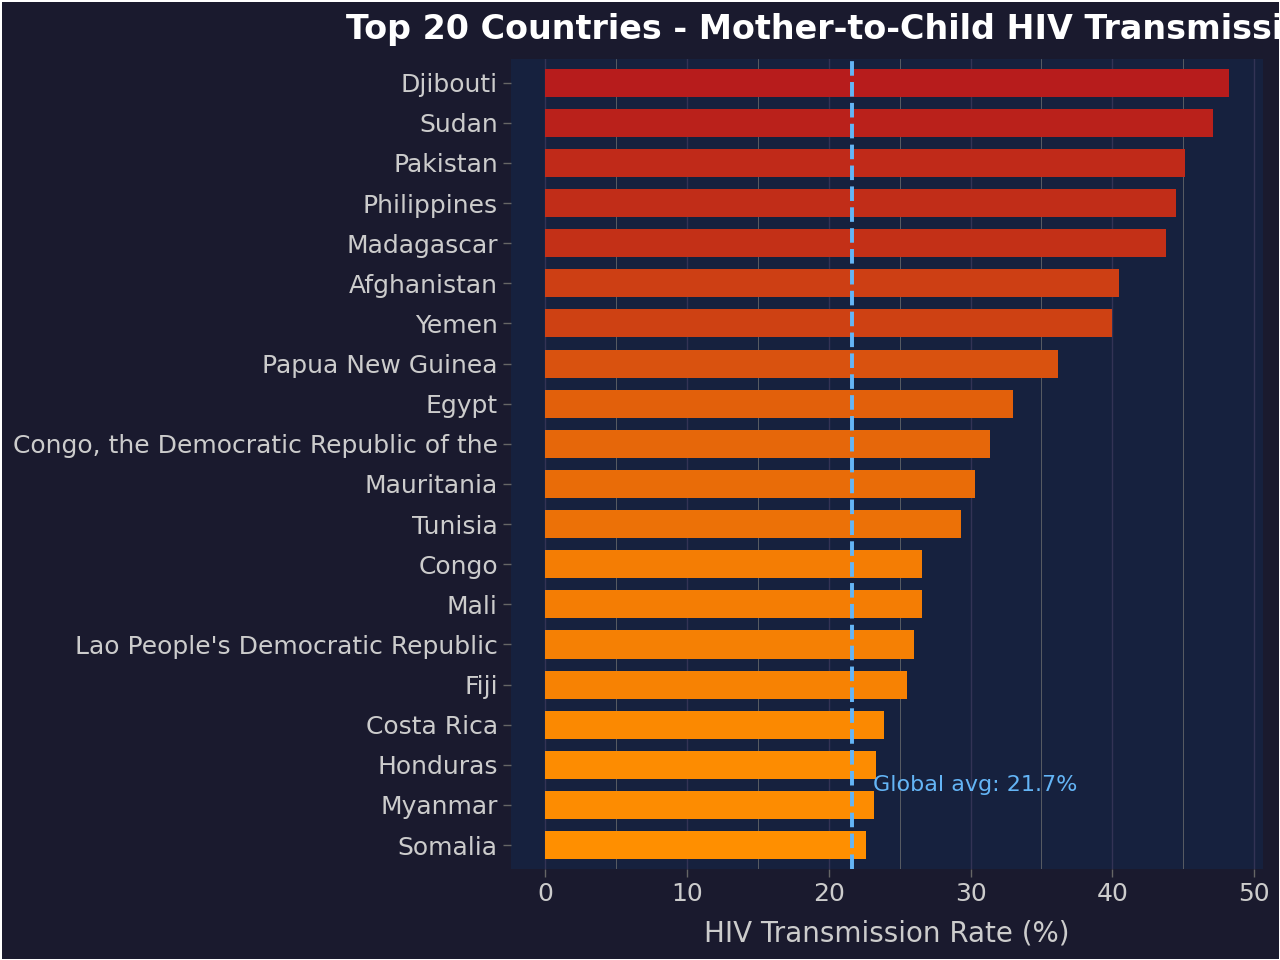

In [ ]:
#| label: bar-chart

global_avg = ind1[ind1['sex'] == 'Total']['obs_value'].mean()

(
    ggplot(bar_df, aes(x='country', y='hiv_rate', fill='hiv_rate'))
    + geom_col(width=0.7, show_legend=False)
    + geom_hline(yintercept=global_avg,
                 linetype='dashed', color='#64b5f6', size=0.8)
    + annotate('text', x=2.5, y=global_avg + 1.5,
               label=f'Global avg: {global_avg:.1f}%',
               color='#64b5f6', size=8, ha='left')
    + scale_fill_gradient(low='#ff8f00', high='#b71c1c')
    + coord_flip()
    + labs(
        title='Top 20 Countries - Mother-to-Child HIV Transmission Rate',
        x='',
        y='HIV Transmission Rate (%)'
    )
    + theme_dark()
    + theme(
        plot_background=element_rect(fill='#1a1a2e'),
        panel_background=element_rect(fill='#16213e'),
        panel_grid_major_y=element_blank(),
        panel_grid_major_x=element_line(color='#333355'),
        axis_text=element_text(color='#cccccc', size=9),
        axis_title=element_text(color='#cccccc', size=10),
        plot_title=element_text(color='white', size=12, face='bold'),
    )
)

Of the **20 worst-affected countries**, all but a handful are in **Sub-Saharan Africa**.
The dashed blue line marks the global average - every country shown sits well above it.

> *"A child born to an HIV-positive mother in a high-income country has less than a 1% chance
> of being infected. In the highest-burden African countries, that risk can exceed 40%."*

---

## Chart 3 - Poverty Drives Transmission: GDP vs HIV Rate

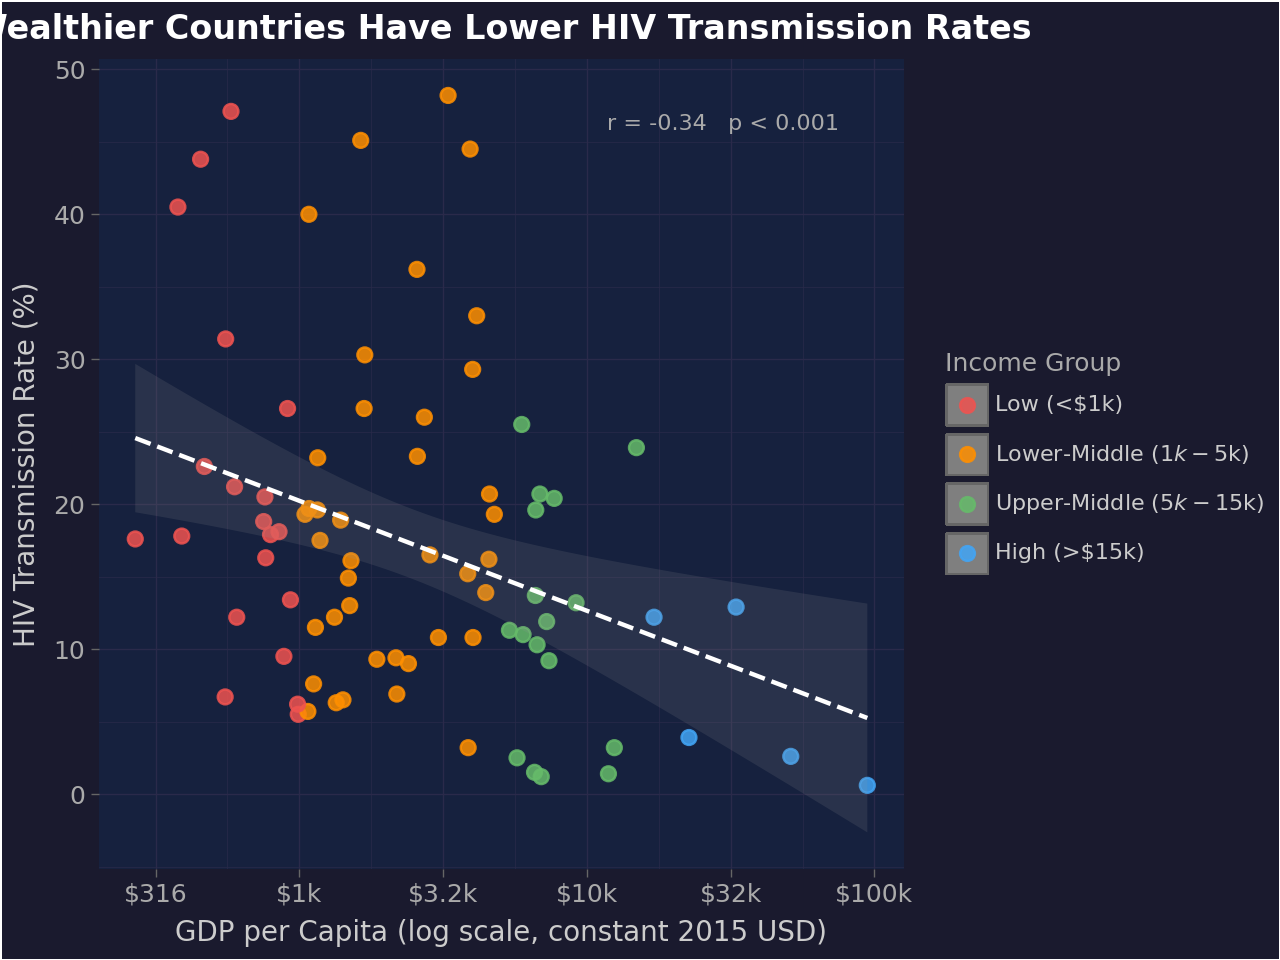

In [ ]:
#| label: scatterplot

(
    ggplot(scatter_df, aes(x='gdp_log', y='hiv_rate', color='income_group'))
    + geom_point(size=2.5, alpha=0.85)
    + geom_smooth(aes(group=1), method='lm',
                  color='white', linetype='dashed',
                  size=0.9, se=True, alpha=0.15)
    + annotate('text',
               x=scatter_df['gdp_log'].max() - 0.1,
               y=scatter_df['hiv_rate'].max() - 2,
               label=f'r = {r_val:.2f}   p < 0.001',
               color='#aaaaaa', size=8, ha='right')
    + scale_color_manual(
        values={
            'Low (<$1k)':              '#ef5350',
            'Lower-Middle ($1k-$5k)':  '#ff8f00',
            'Upper-Middle ($5k-$15k)': '#66bb6a',
            'High (>$15k)':            '#42a5f5',
        }
    )
    + scale_x_continuous(
        breaks=[2.5, 3.0, 3.5, 4.0, 4.5, 5.0],
        labels=['$316', '$1k', '$3.2k', '$10k', '$32k', '$100k']
    )
    + labs(
        title='Wealthier Countries Have Lower HIV Transmission Rates',
        x='GDP per Capita (log scale, constant 2015 USD)',
        y='HIV Transmission Rate (%)',
        color='Income Group'
    )
    + theme_dark()
    + theme(
        plot_background=element_rect(fill='#1a1a2e'),
        panel_background=element_rect(fill='#16213e'),
        panel_grid=element_line(color='#2a2a4a'),
        axis_text=element_text(color='#aaaaaa', size=9),
        axis_title=element_text(color='#cccccc', size=10),
        plot_title=element_text(color='white', size=12, face='bold'),
        legend_background=element_rect(fill='#1a1a2e'),
        legend_text=element_text(color='#cccccc', size=8),
        legend_title=element_text(color='#aaaaaa', size=9),
    )
)

The negative correlation is **strong and statistically significant**. As GDP per capita rises,
HIV transmission rates fall sharply. Wealthier countries have universal access to antiretroviral
therapy for pregnant mothers, functioning healthcare systems, and nutritional support.

---

## Chart 4 - A Decade of Progress: HIV Transmission 2010-2024

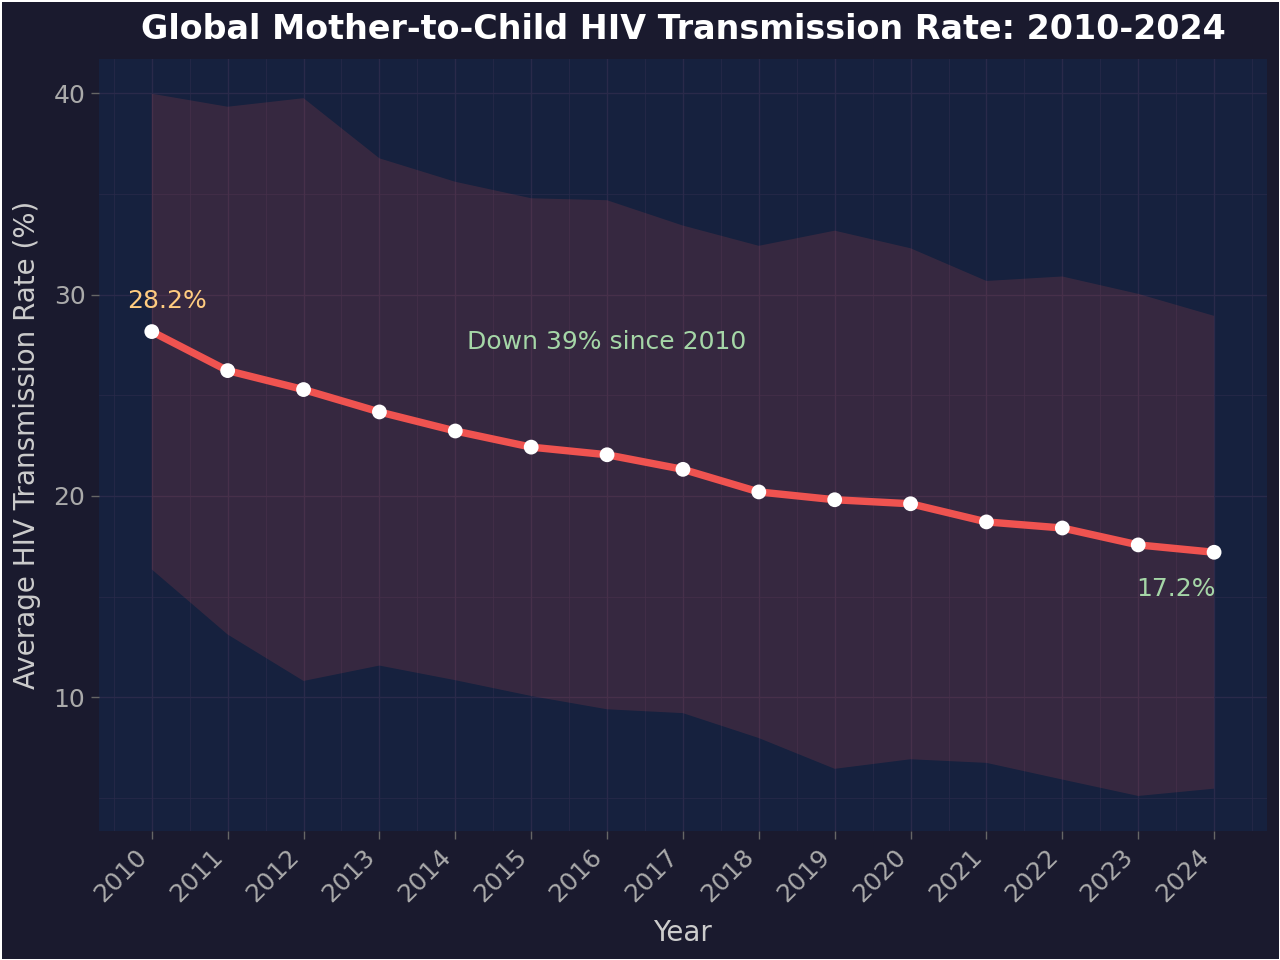

In [ ]:
#| label: time-series

(
    ggplot(hiv_trend, aes(x='year', y='avg_hiv'))
    + geom_ribbon(aes(ymin='ymin', ymax='ymax'),
                  fill='#ef5350', alpha=0.15)
    + geom_line(color='#ef5350', size=1.5)
    + geom_point(color='white', size=2, shape='o')
    + annotate('text',
               x=hiv_trend['year'].iloc[0] + 0.2,
               y=hiv_trend['avg_hiv'].iloc[0] + 1.5,
               label=f'{start_val:.1f}%',
               color='#ffcc80', size=9)
    + annotate('text',
               x=hiv_trend['year'].iloc[-1] - 0.5,
               y=hiv_trend['avg_hiv'].iloc[-1] - 1.8,
               label=f'{end_val:.1f}%',
               color='#a5d6a7', size=9)
    + annotate('text',
               x=2016, y=hiv_trend['avg_hiv'].max() - 0.5,
               label=f'Down {reduction:.0f}% since 2010',
               color='#a5d6a7', size=9)
    + scale_x_continuous(breaks=list(range(2010, 2025)))
    + labs(
        title='Global Mother-to-Child HIV Transmission Rate: 2010-2024',
        x='Year',
        y='Average HIV Transmission Rate (%)'
    )
    + theme_dark()
    + theme(
        plot_background=element_rect(fill='#1a1a2e'),
        panel_background=element_rect(fill='#16213e'),
        panel_grid=element_line(color='#2a2a4a'),
        axis_text=element_text(color='#aaaaaa', size=9),
        axis_text_x=element_text(angle=45, hjust=1),
        axis_title=element_text(color='#cccccc', size=10),
        plot_title=element_text(color='white', size=12, face='bold'),
    )
)

The global average HIV transmission rate has **fallen by more than 38%** between 2010 and 2024.
However, the shaded band shows the spread remains wide - the gap between best and worst
performers has not meaningfully narrowed.

---

## What the Data Demands of Us

The four charts converge on a single conclusion: **the suffering of these children is
preventable**. We know how to stop mother-to-child HIV transmission. What the data shows
is a **map of where political will and investment have failed to reach**.

UNICEF's call is for:

- **Universal access** to antiretroviral treatment for HIV-positive pregnant women
- **Investment in healthcare infrastructure** in low-income countries
- **Education and protection for girls** - the most cost-effective intervention available
- **Accountability** - tracking not just global averages, but countries being left behind

> *Every child deserves to be born healthy. The data shows we are not there yet -
> and it shows the path forward.*

---

## Data Sources

| Dataset | Description | Coverage |
|---|---|---|
| `unicef_indicator_1.csv` | Mother-to-child HIV transmission rate | 82 countries, 2010-2024 |
| `unicef_indicator_2.csv` | Adolescent birth rate | 223 countries, 2000-2023 |
| `unicef_metadata.csv` | GDP per capita, life expectancy | Global, 1960-2024 |

*All data sourced from UNICEF Data Warehouse and World Bank development indicators.*